# 01. Data Exploration and Phase 1 Preparation

Load the two SNAP Reddit hyperlink files, clean the schema, preserve title/body source, apply the course-scale k-core filter, and export chronological splits.

In [1]:
from pathlib import Path
import sys

root = Path.cwd()
if not (root / 'data').exists():
    root = root.parent
sys.path.insert(0, str(root))

from src.phase1 import combine_raw_datasets, summarize_hyperlinks, apply_k_core_filter, temporal_split

raw_dir = root / 'data' / 'raw'
interim_dir = root / 'data' / 'interim'
processed_dir = root / 'data' / 'processed'
phase1_dir = processed_dir / 'phase1'
interim_dir.mkdir(parents=True, exist_ok=True)
processed_dir.mkdir(parents=True, exist_ok=True)
phase1_dir.mkdir(parents=True, exist_ok=True)

body_path = raw_dir / 'soc-redditHyperlinks-body.tsv'
title_path = raw_dir / 'soc-redditHyperlinks-title.tsv'
body_path, title_path

(WindowsPath('H:/chuong_trinh_hoc_UEH/mon_hoc_ki_6/social_media_data_analysis/Project/Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning/data/raw/soc-redditHyperlinks-body.tsv'),
 WindowsPath('H:/chuong_trinh_hoc_UEH/mon_hoc_ki_6/social_media_data_analysis/Project/Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning/data/raw/soc-redditHyperlinks-title.tsv'))

In [2]:
combined = combine_raw_datasets(body_path, title_path)
summary = summarize_hyperlinks(combined)
summary

{'rows': 858488,
 'unique_source_subreddits': 55863,
 'unique_target_subreddits': 34572,
 'timestamp_min': Timestamp('2013-12-31 16:20:20'),
 'timestamp_max': Timestamp('2017-04-30 16:58:21'),
 'sentiment_counts': {np.int64(1): 776278, np.int64(-1): 82210},
 'top_source_subreddits': source_subreddit
 subredditdrama      27636
 bestof              21170
 titlegore            9503
 shitredditsays       7839
 drama                6784
 shitpost             6658
 circlebroke2         6583
 switcharoo           6039
 shitamericanssay     5963
 hailcorporate        5360
 Name: count, dtype: Int64,
 'top_target_subreddits': target_subreddit
 askreddit        26622
 iama             13446
 pics             12578
 todayilearned    11124
 funny            10777
 videos           10013
 worldnews         9944
 news              7692
 politics          6114
 gaming            6097
 Name: count, dtype: Int64}

In [3]:
filtered = apply_k_core_filter(combined, k=5)
train_df, validation_df, test_df = temporal_split(filtered)

combined.to_csv(interim_dir / 'phase1_combined_clean.csv', index=False)
filtered.to_csv(phase1_dir / 'phase1_kcore_filtered.csv', index=False)
train_df.to_csv(phase1_dir / 'phase1_train.csv', index=False)
validation_df.to_csv(phase1_dir / 'phase1_validation.csv', index=False)
test_df.to_csv(phase1_dir / 'phase1_test.csv', index=False)

{
    'combined_rows': len(combined),
    'filtered_rows': len(filtered),
    'train_rows': len(train_df),
    'validation_rows': len(validation_df),
    'test_rows': len(test_df),
}

{'combined_rows': 858488,
 'filtered_rows': 708425,
 'train_rows': 619294,
 'validation_rows': 43048,
 'test_rows': 46083}

## Direct EDA Visualizations

These charts are rendered inline for quick inspection in the notebook.

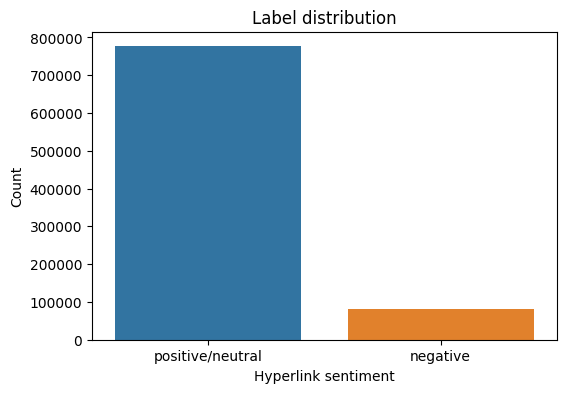

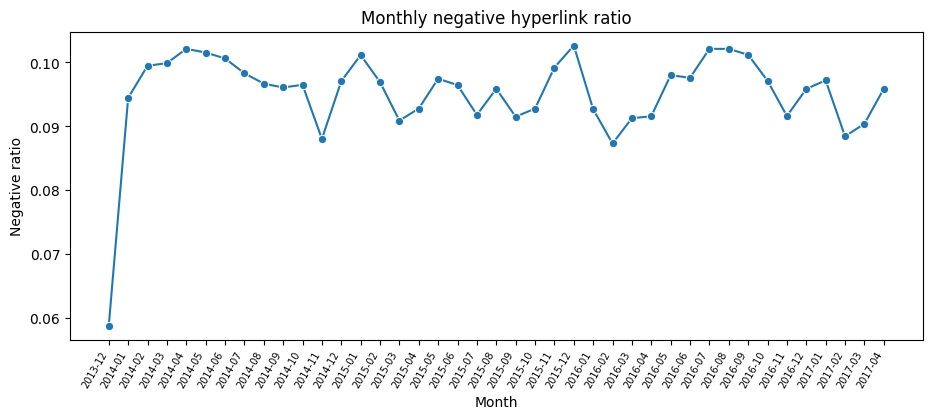

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

label_counts = combined['link_sentiment'].map({1: 'positive/neutral', -1: 'negative'}).value_counts()
plt.figure(figsize=(6, 4))
sns.barplot(x=label_counts.index, y=label_counts.values, hue=label_counts.index, legend=False)
plt.title('Label distribution')
plt.xlabel('Hyperlink sentiment')
plt.ylabel('Count')
plt.show()

monthly = combined.assign(month=combined['timestamp'].dt.to_period('M').astype(str))
monthly = monthly.groupby('month')['link_sentiment'].agg(total='size', negative=lambda values: int((values == -1).sum())).reset_index()
monthly['negative_ratio'] = monthly['negative'] / monthly['total']
plt.figure(figsize=(11, 4))
sns.lineplot(data=monthly, x='month', y='negative_ratio', marker='o')
plt.title('Monthly negative hyperlink ratio')
plt.xlabel('Month')
plt.ylabel('Negative ratio')
plt.xticks(rotation=60, ha='right', fontsize=7)
plt.show()